# **Missing data patterns: UCI diabetes dataset case study**

This case study uses the "Diabetes 130-US Hospitals for Years 1999-2008" dataset (UCI-296; https://doi.org/10.24432/C5230J).
The dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license.
This copy of the dataset was downloaded on 2024-04-22.

# Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from vizdataquality import calculate as vdqc
from vizdataquality import plot as vdqp
from vizdataquality import utils as vdqu

from vizdataquality import missing_data_functions as mdf
from vizdataquality import missing_data_plots as mdp
from vizdataquality import missing_data_utils as mdu
from vizdataquality import explanation_graph as eg

# Read data file

In [2]:
input_filename = os.path.join('../../examples', 'UCI-296_diabetes.csv')
encoding_results = vdqu.detect_file_encoding(input_filename, read_in_chunks=False)
# Some of the variables contain the valid value 'None', which by default Pandas would have interpreted as missing
df = pd.read_csv(input_filename, encoding=encoding_results['encoding'], low_memory=False, na_values='',
                 keep_default_na=False)

# Change these columns from int to object
for col in ['admission_source_id', 'admission_type_id', 'discharge_disposition_id', 'encounter_id', 'patient_nbr']:
    df[col] = df[col].astype('object')
    
columns = df.columns.tolist()
columns.sort()
df = df[columns]

# Computation

## High-level profiling statistics for each variable

In [3]:
df_output = vdqc.calc(df)

## Missingness intersections and cardinality

In [4]:
# Calculate the following:
#
# num_missing : Series
# The number of missing values in each variable
#
# intersection_id_to_columns : DataFrame
# A row for each combination of missing/present variables, and a column for each variable (set to True if value is missing, or False if value is present in that combination)
#
# intersection_id_to_records : DataFrame
# A row for each record. The index is an intersection ID (usually not unique) and the column contains a record ID (not in any particular order)
#
num_missing, intersection_id_to_columns, intersection_id_to_records = mdf.get_intersections_from_dataframe(df)
# Series that contains the count for each intersection (i.e., the number of records that are missing that combination of variables)
intersection_cardinality = mdf.get_intersection_cardinality(intersection_id_to_records)

# Series that contains the degree for each intersection (i.e., the number of variables that are missing)
ideg = mdf.get_intersection_degree(intersection_id_to_columns)
intersection_degree = ideg[ideg > 0]

print('Number of intersections', len(intersection_degree))
print('Intersection cardinality minimum', intersection_cardinality.min(), 'maximum', intersection_cardinality.max())
print('Intersection degree minimum', intersection_degree.min(), 'maximum', intersection_degree.max())

# Number of variables and records in the data frame
num_columns = intersection_id_to_columns.shape[1]
num_records = intersection_id_to_records.shape[0]
print('Number of columns', num_columns)
print('Number of records', num_records)

# Number of values (i.e., not missing) in each variable
num_present = num_records - num_missing

# Get the number of unique values in each variable (excluding missing values)
num_unique = df.nunique(dropna=True)

Number of intersections 53
Intersection cardinality minimum 1 maximum 31197
Intersection degree minimum 1 maximum 5
Number of columns 50
Number of records 101766


# Plots

## Dataset overview
Plots showing missingness in dataset as a whole.

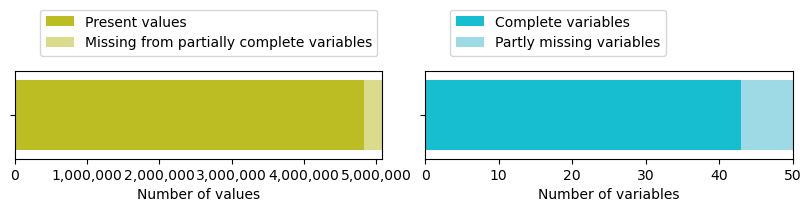

In [5]:
fig_kw = {'size_inches': (8, 2), 'constrained_layout': True}
legend_kw = {'bbox_to_anchor': (0.05, 1.1)}
mdp.plot_summary_missingness(num_records, num_missing, vert=False, fig_kw=fig_kw, legend_kw=legend_kw)

## Variable overview
(A) is a normal bar chart that makes diag 1 and diag 2 appear to be complete, because there are too few missing
values (21 and 358, respectively) for the bars to be visible.
(B) does not have that issue, because perceptual discontinuity has been applied to make all the non-zero bars long
enough to be seen.

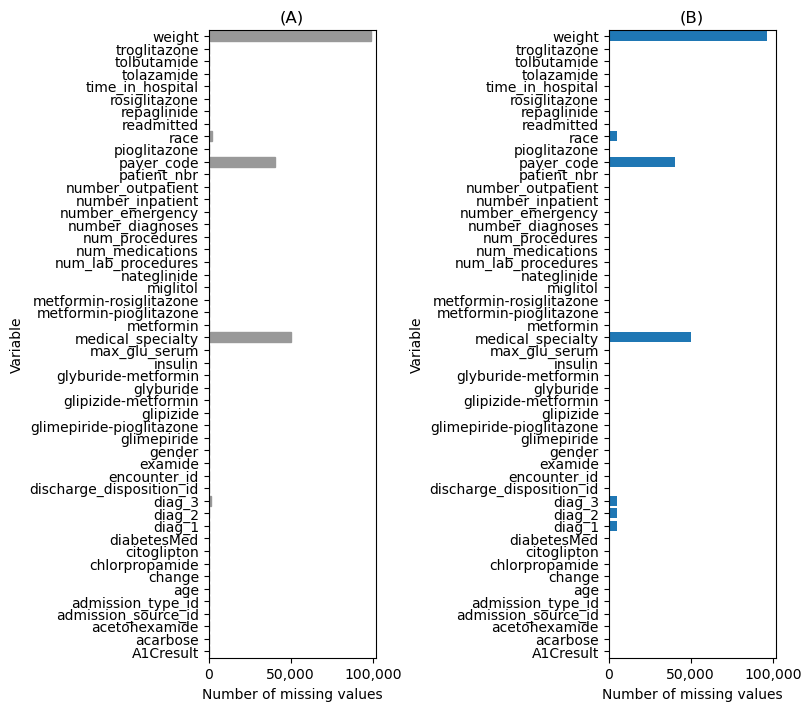

In [6]:
# Multiple columns of plots
fig, axs = plt.subplots(1, 2)
fig_kw = {'constrained_layout': True, 'size_inches': (8, 7)}
fig.set(**fig_kw)
ax_kw = {'xlim': (0, num_records)}

for l1 in range(len(axs)):
    ax_kw['title'] = '(A)' if l1 == 0 else '(B)'
    if l1 == 0:
        colour = [0.6, 0.6, 0.6]
        vdqp.scalar_bar(df_output['Number of missing values'], perceptual_threshold=None, ax_input=axs[l1], vert=False, ax_kw=ax_kw, color=colour, ec=colour)
    else:
        vdqp.scalar_bar(df_output['Number of missing values'], ax_input=axs[l1], vert=False, ax_kw=ax_kw)

plt.show()

## Combination heatmap
The 53 combinations of variables that are missing together.
The most common combination (31,197 records) is weight and medical specialty.

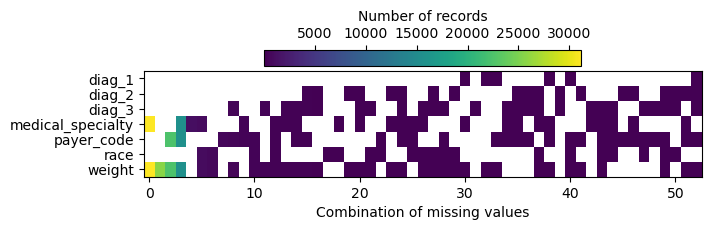

In [7]:
dftmp = mdf.get_intersection_heatmap_data(intersection_id_to_columns, intersection_cardinality)
# Sort the heatmap so the combinations are in ascending cardinality order
dftmp['_max'] = dftmp.max(axis=1)
df_heatmap = dftmp.sort_values(by='_max', ascending=False).drop(columns='_max')

fig_kw = {'constrained_layout': True, 'size_inches': (7, 2.2)}
ax_kw = {'xlabel': 'Combination of missing values'}
cbar_kw = {'location': 'top', 'label': 'Number of records', 'shrink': 0.6}

mdp.plot_intersection_heatmap(df_heatmap, transpose=True, xlabels_rotate=90, fig_kw=fig_kw, ax_kw=ax_kw,
                              cbar_kw=cbar_kw, aspect='auto')    

## Purity overview
The disjoint, block and monotone pattern purity of each pair of incomplete variables.
In each chart the pairs have been plotted in ascending purity order.

In [8]:
patterns = mdu.PATTERNS
threshold = 0.0
df_patterns = mdf.get_missiness_pattern(num_missing, intersection_id_to_columns, intersection_cardinality, patterns, threshold)

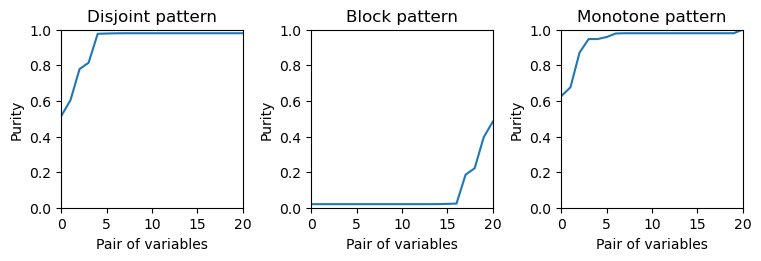

In [9]:
# Get a series containing the pairwise purities for every type of pattern
purities = [df_patterns[df_patterns['Pattern'] == i]['Purity'] for i in mdu.PATTERNS]
names = [i.capitalize() + ' pattern' for i in mdu.PATTERNS]
# Plot the purities
ax_kw = {'ylim': (0.0, 1.0), 'title': names}
fig_kw = {'size_inches': (7.5, 2.5), 'constrained_layout': True}
mdp.plot_purity_of_patterns(purities, perceptual_threshold=0.02, fig_kw=fig_kw, ax_kw=ax_kw)

## Purity heatmap
The most pure pattern for each pair of incomplete variables.
The labels show each pair’s purity value.

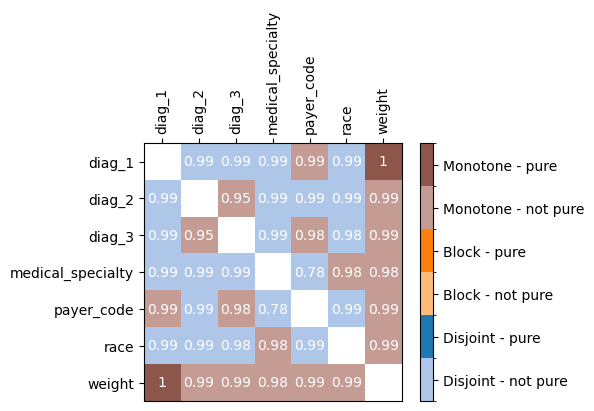

In [10]:
fig_kw = {'size_inches': (6, 4), 'constrained_layout': True}
mdp.plot_purity_heatmap(df_patterns, threshold=0.5, xlabels_rotate=90, datalabels=True, fig_kw=fig_kw)

# Explanation graph

In [11]:
# Quantitative colourblind safe colours partly from ColorBrewer (https://colorbrewer2.org)
colour_yes = (.400, .761, .647) # green
colour_neutral = (.812,.812,.812) #grey
colour_no = (.988, .553, .384) # orange

shape_explain = 'ellipse'
shape_notexplain = 'square'

bbox_explain_yes = {'facecolor': colour_yes, 'boxstyle': shape_explain}
bbox_explain_neutral = {'facecolor': colour_neutral, 'boxstyle': shape_explain}
bbox_explain_no = {'facecolor': colour_no, 'boxstyle': shape_explain}

bbox_notexplain_yes = {'facecolor': colour_yes, 'boxstyle': shape_notexplain}
bbox_notexplain_neutral = {'facecolor': colour_neutral, 'boxstyle': shape_notexplain}
bbox_notexplain_no = {'facecolor': colour_no, 'boxstyle': shape_notexplain}

# Initialise the graph
graph = eg.Explanation_Graph(intersection_id_to_columns, intersection_cardinality, criteria=eg.CHECK_COLUMNS)

## weight

In [12]:
cols = 'weight'
intersections = graph.get_intersections(cols)

caption = 'weight'
description = 'Hospitals and clinics were not required to record weight.'
graph.add_node(eg.Explanation_Node(cols, intersections, caption, description, bbox_attributes=bbox_explain_neutral))

## Explanation summary (so far)
The percentage of missing values, records and combinations that are accounted for just by the weight variable.
The partly and not explained values, records and combinations involve some of the other six variables that are sometimes missing.

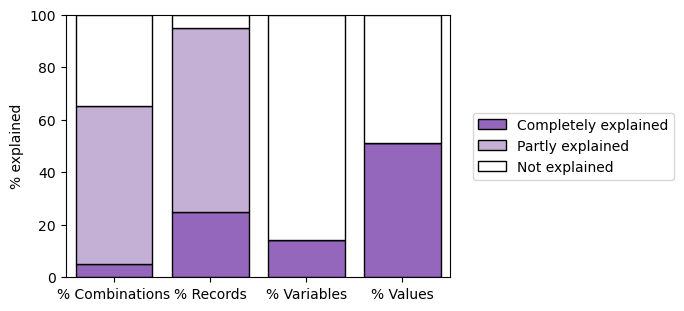

In [13]:
df_summ = graph.get_summary()

fig_kw = {'size_inches': (6, 3), 'constrained_layout': True}
ax_kw = {'title': '', 'ylabel': '% explained', 'ylim': (0, 100)}
legend_kw = {'loc': 'right', 'bbox_to_anchor': (1.6, 0.5)}
mdp.plot_explanation_graph_summary(df_summ, fig_kw=fig_kw, ax_kw=ax_kw, legend_kw=legend_kw)

## diag_1 and weight missing together

In [14]:
dfs = df_patterns[df_patterns['Purity']>=1.0]
# Get the variable in each column
cols = list(dfs['Column1'].values) + list(dfs['Column2'].values)
intersections = graph.get_intersections(cols, all_cols=True)

caption = 'diag_1, weight'
description = 'If diag_1 is missing then weight is the only other variable that is also always missing. That is despite the fact that diag_1 is only missing a few records, whereas weight and some other variables are missing in most records.'
graph.add_node(eg.Explanation_Node(cols, intersections, caption, description, bbox_attributes=bbox_notexplain_no))

#### diag_1, diag_2 and diag_3 missing together

In [15]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']
ints_no_diags = graph.get_intersections(diag_cols, all_cols=True)
caption = 'All diag_N missing'
description = 'All three diagnosis variables are missing.'
graph.add_node(eg.Explanation_Node(diag_cols, ints_no_diags, caption, description, bbox_attributes=bbox_notexplain_no))

### diag_1 missing, but diag_2 and diag_3 present (and vice versa)

In [16]:
cols = ['diag_1', ['diag_2', 'diag_3']]
list_of_sets = graph.get_column_combination_intersections(cols[0], cols[1], get_AB=False, get_not_AB=False)
captions = ['Only diag_1', 'diag_2 and diag_3']
descriptions = ['diag_1 missing, but other diag present.',
               'diag_2 and diag_3 missing, but diag_1 is present.']
bboxattrib = [bbox_explain_no, bbox_explain_yes]
slist = []

for l1 in range((len(list_of_sets))):
    slist.append(eg.Explanation_Node(cols[l1], list_of_sets[l1], captions[l1], descriptions[l1], bbox_attributes=bboxattrib[l1]))

graph.add_node(slist)

### diag_2 missing but diag_3 present (and vice versa)

In [17]:
cols = ['diag_2', 'diag_3']
list_of_sets = graph.get_column_combination_intersections(cols[0], cols[1], get_AB=False, get_not_AB=False)
captions = ['Only diag_2', 'Only diag_3']
descriptions = ['diag_2 missing, but diag_3 present.', 'diag_3 missing, but diag_2 present.']
bboxattrib = [bbox_explain_no, bbox_explain_yes]

for l1 in range((len(list_of_sets))):
    graph.add_node(eg.Explanation_Node(cols[l1], list_of_sets[l1], captions[l1], descriptions[l1], bbox_attributes=bboxattrib[l1]))

### medical_specialty and payer_code both missing, then each missing by itself

In [18]:
cols = ['medical_specialty', 'payer_code']
list_of_sets = graph.get_column_combination_intersections(cols[0], cols[1], get_not_AB=False)
captions = ['medical_specialty & payer_code', 'Only medical_specialty', 'Only payer_code']
descriptions = ['Both medical_specialty and payer_code are missing.',
                'medical_specialty missing, but payer_code is present.',
               'payer_code missing, but medical_specialty is present.']

for l1 in range((len(list_of_sets))):
    graph.add_node(eg.Explanation_Node(cols if l1 == 0 else cols[l1-1], list_of_sets[l1], captions[l1], descriptions[l1], bbox_attributes=bbox_notexplain_neutral))
    print(captions[l1], 'Number of records = ', intersection_cardinality.iloc[list(list_of_sets[l1])].sum())

medical_specialty & payer_code Number of records =  16354
Only medical_specialty Number of records =  49949
Only payer_code Number of records =  40256


### race

In [19]:
cols = 'race'
intersections = graph.get_intersections(cols)

caption = 'race'
description = 'race is missing.'
graph.add_node(eg.Explanation_Node(cols, intersections, caption, description, bbox_attributes=bbox_notexplain_neutral))

## Summary of explanations
This shows that all of the combinations, records, variables and values are included in the explanation graph.

                      Combinations  Records  Variables  Values
Category                                                      
Completely explained            53   100723          7  192849
Partly explained                 0        0          0       0
Not explained                    0        0          0       0


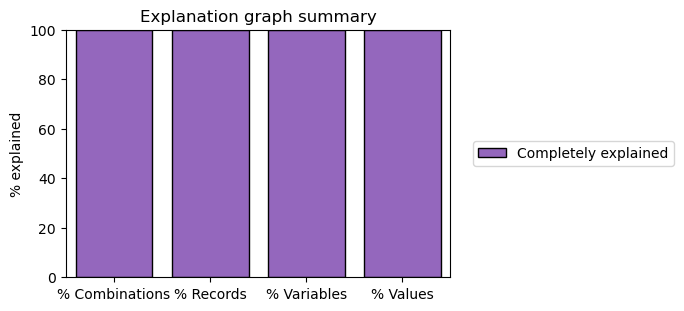

In [20]:
df_summ = graph.get_summary()
print(df_summ)

fig_kw = {'size_inches': (6, 3), 'constrained_layout': True}
ax_kw = {'title': 'Explanation graph summary', 'ylabel': '% explained', 'ylim': (0, 100)}
legend_kw = {'loc': 'right', 'bbox_to_anchor': (1.6, 0.5)}
mdp.plot_explanation_graph_summary(df_summ, fig_kw=fig_kw, ax_kw=ax_kw, legend_kw=legend_kw)


# Explanation graph (automatic layout)

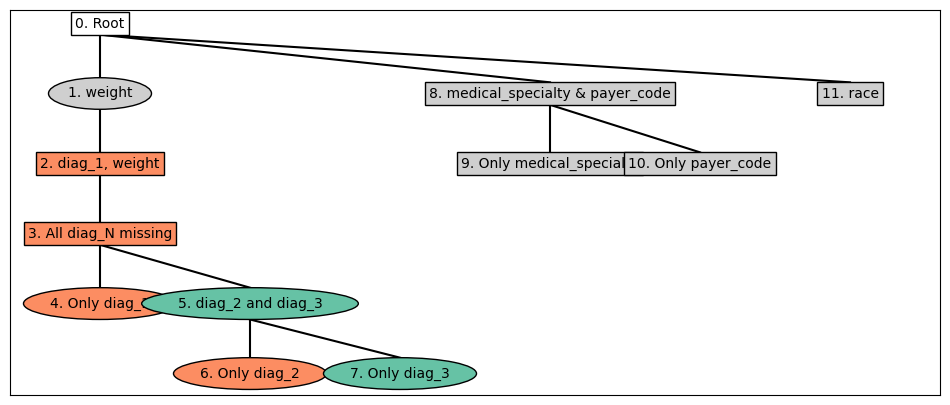

In [21]:
fig_kw = {'size_inches': (12, 5)}
mdp.plot_explanation_graph_diagram(graph, fig_kw=fig_kw)

# Customised layout
Adjust the position of some nodes.

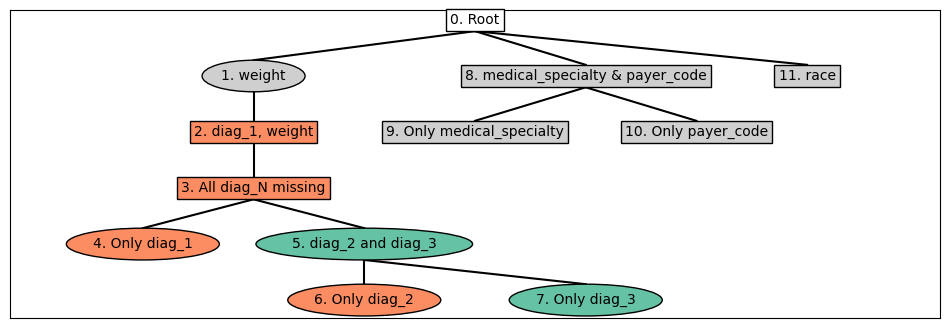

In [22]:
npos = {}
npos[0] = {'x': 1.5}

for i in [1,2,3]:
    npos[i] = {'x': 0.5}
    
npos[8] = {'x': 2}
npos[9] = {'x': 1.5}
npos[10] = {'x': 2.5}
npos[11] = {'x': 3}
    
fig_kw = {'size_inches': (12, 4)}
mdp.plot_explanation_graph_diagram(graph, node_positions=npos, fig_kw=fig_kw)